In [1]:
#Basic Setup
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import numpy as np
import uproot
import pandas as pd
import matplotlib.ticker as mticker
import math
#open root file


#df = uproot.open(
 #   "/volatile/clas12/cooperb/SULI/pid_training_test.root:PhysicsEvents"
#).arrays(library="pd")
cols = ["pid", "p", "theta", "beta", "chi2pid", "rich_RQ", "vz", "sector", "phi"]
kinematics =["Mx_eKX", "Q2", "W", "y"]

for kin in kinematics:
    cols.append(kin)

#cols = ["mc_matching_pid","ftof_energy_1A", "ftof_energy_1B", "ftof_time_1A", "ftof_time_1B", "ftof_path_1A", "ftof_path_1B", "ecin_energy", "ecout_energy", "ecin_time", "ecout_time", "ecin_path", "ecout_path", "nphe_htcc"]

df = uproot.open("/volatile/clas12/cooperb/SULI/pid_training_v2.root:PhysicsEvents").arrays(cols, library="pd")
real =uproot.open("/volatile/clas12/cooperb/SULI/data_pid_training_test.root:PhysicsEvents").arrays(cols, library="pd")
#creates a list of matching events (excludes events that failed matching)
#matched = df[df["mc_matching_pid"] != -9999].copy()
#baseline = matched[(matched["p"]>=1)&(matched["p"]<=5)&(matched["mc_matching_pid"]==321)&passes_kplus_chi2pid_cut(matched["chi2pid"], matched["p"])]
#baseline = matched[(matched["p"]>=1)&(matched["p"]<=5)&(abs(matched["chi2pid"])<1)]
direct = "/work/clas12/CooperBe/Argonne2026/suli2026_pid/figures/audit/DATAcompare/group1/"  #path directory for saving pngs :)
#matched=baseline

#matched = matched[(matched["nphe_htcc"]!=-9999)&(matched["nphe_htcc"]!=0)]
#print("ftof_path_1A:  ", matched["nphe_htcc"].describe())
#print("\nQuick eyeball:")
#print(f"  ftof_time_1A range: [{matched['nphe_htcc'].min():.2f}, {matched['nphe_htcc'].max():.2f}]")

allPlots =[]



In [2]:
baseline=df[
(df["Q2"]>2)&
(df["W"]>2)&
(df["Mx_eKX"]>1.6)&
((df["y"]>0)&(df["y"]<0.75))
]
df=baseline

baseline=real[
(real["Q2"]>2)&
(real["W"]>2)&
(real["Mx_eKX"]>1.6)&
((real["y"]>0)&(real["y"]<0.75))
]
real=baseline

In [3]:
ranges=[
[-2212, 2212], #pid
[0.5, 5],    #p
[4, 44], #theta
[0, 1],  #beta  
[-10, 10], #chi2pid
[0,1], #rich_RQ
[-10,2], #Vz (Real data has hard cut a 0.6
[0, 6], #sector
[0,360],  #Phi
[0,5], #Mx
[0,5], #Q2
[0,5], #W
[0,1] #y
]    

parts = [321, 211, 2212]
colors= ["Red", "Blue"]
labels=["Data", "Monte-Carlo"]

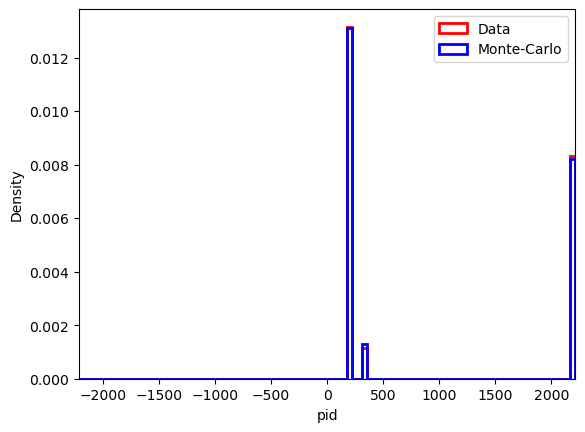

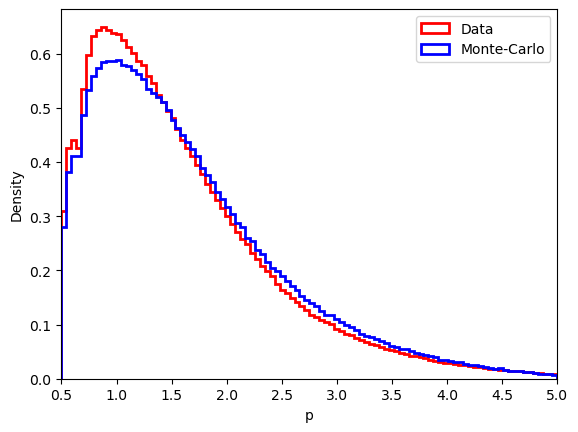

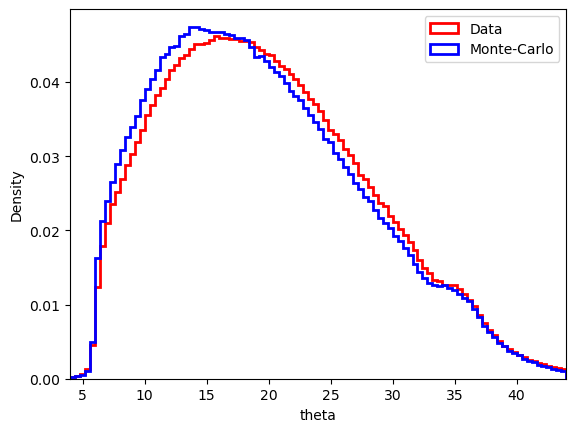

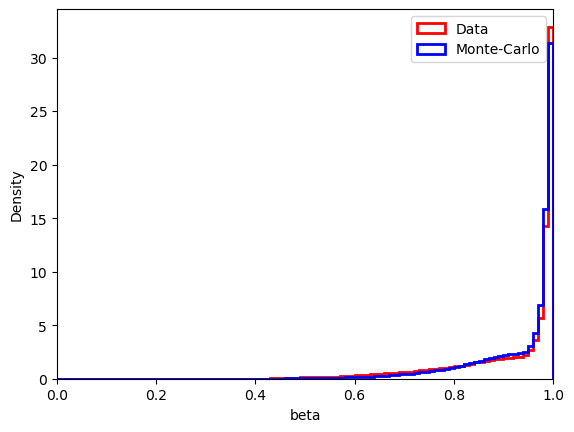

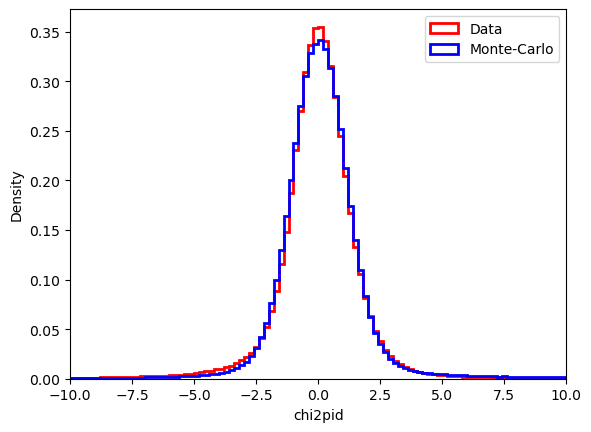

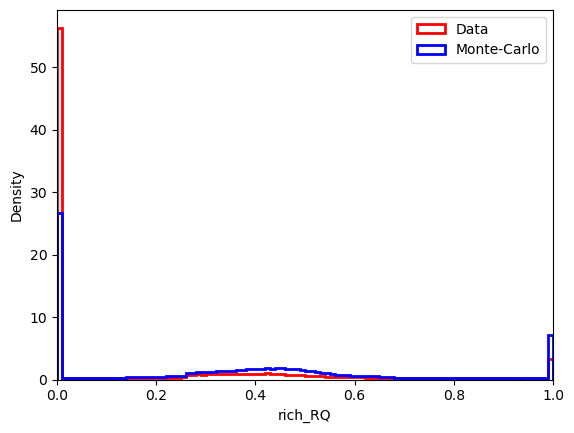

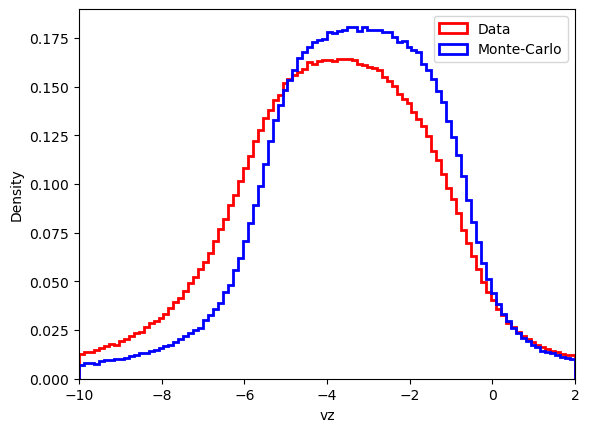

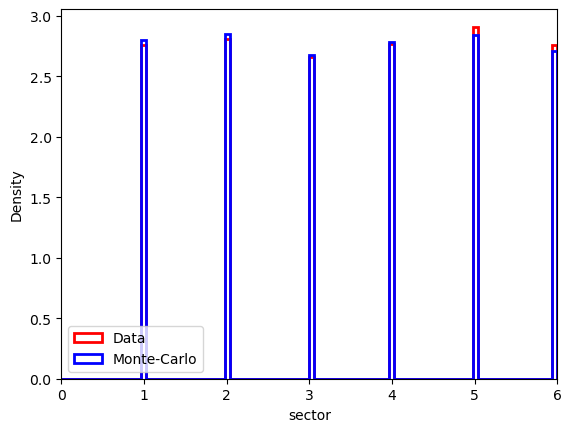

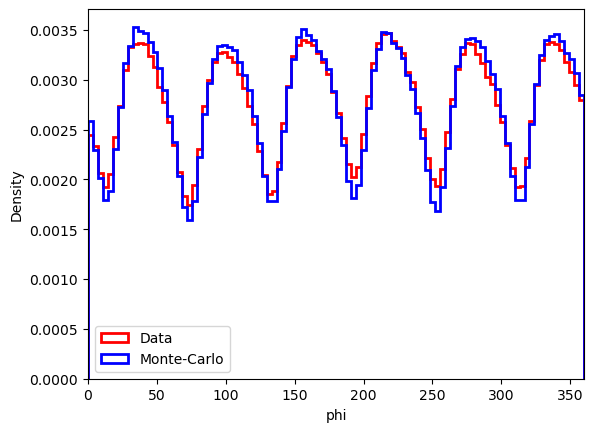

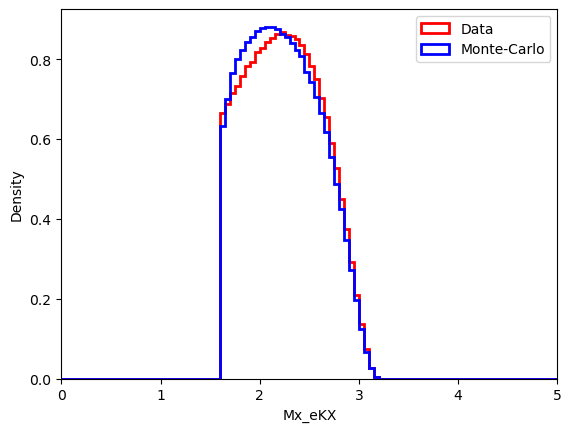

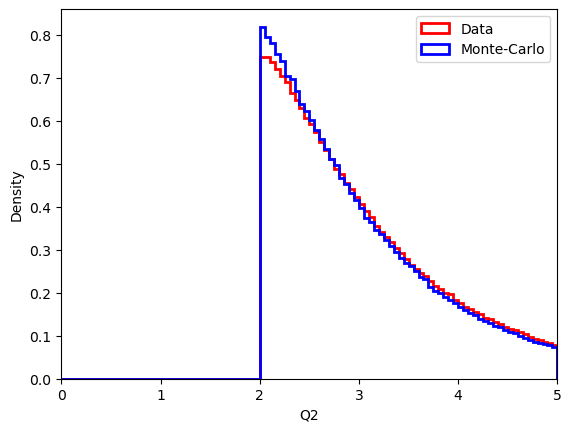

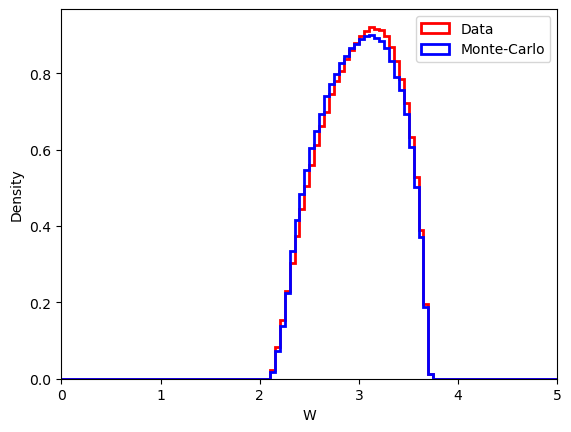

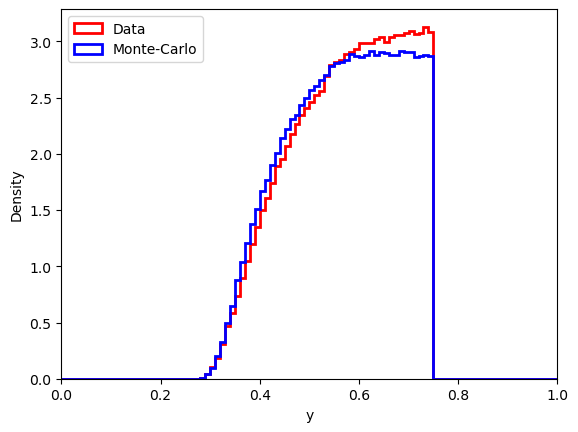

In [4]:
cnt=0
for varbs in cols:
    tdf =df[(df[varbs]!=-9999)]
    treal =real[(real[varbs]!=-9999)]
    dfs=[real,df]
    fig, ax = plt.subplots()
    for i, df in enumerate(dfs):
            ax.hist(
                dfs[i][varbs],
                bins=100,
                range=(ranges[cnt][0], ranges[cnt][1]),
                histtype='step',
                color=colors[i],
                density=True,
                linewidth=2,
                label=labels[i]
            )
    ax.set_xlim(ranges[cnt][0], ranges[cnt][1])
    ax.set_xlabel(varbs)
    ax.set_ylabel("Density")
    ax.legend()
    fig.savefig(direct+varbs+"CompareDATA.png", dpi=150)
    allPlots.append(fig)
    cnt=cnt+1
    plt.show()

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import uproot
import pandas as pd
import matplotlib.ticker as mticker
import math

#cols = ["pid", "mc_matching_pid", "p", "theta", "beta", "chi2pid", "rich_RQ", "vz", "sector", "phi"]
cols = ["pid","ftof_energy_1A", "ftof_energy_1B", "ftof_time_1A", "ftof_time_1B", "ftof_path_1A", "ftof_path_1B", "ecin_energy", "ecout_energy", "ecin_time", "ecout_time", "ecin_path", "ecout_path", "nphe_htcc"]
kinematics =["Mx_eKX", "Q2", "W", "y"]

for kin in kinematics:
    cols.append(kin)


df = uproot.open("/volatile/clas12/cooperb/SULI/pid_training_v2.root:PhysicsEvents").arrays(cols, library="pd")
real =uproot.open("/volatile/clas12/cooperb/SULI/data_pid_training_test.root:PhysicsEvents").arrays(cols, library="pd")
#creates a list of matching events (excludes events that failed matching)

baseline=df[
(df["Q2"]>2)&
(df["W"]>2)&
(df["Mx_eKX"]>1.6)&
((df["y"]>0)&(df["y"]<0.75))
]
df=baseline

baseline=real[
(real["Q2"]>2)&
(real["W"]>2)&
(real["Mx_eKX"]>1.6)&
((real["y"]>0)&(real["y"]<0.75))
]
real=baseline


print("ftof_path_1A:  ", real["ftof_time_1A"].describe())
print("\nQuick eyeball:")
print(f"  ftof_time_1A range: [{real['ftof_time_1A'].min():.2f}, {real['ftof_time_1A'].max():.2f}]")

ftof_path_1A:   count    2.101725e+06
mean    -3.048055e+03
std      4.621996e+03
min     -9.999000e+03
25%     -9.999000e+03
50%      2.378484e+01
75%      2.508331e+01
max      9.593449e+01
Name: ftof_time_1A, dtype: float64

Quick eyeball:
  ftof_time_1A range: [-9999.00, 95.93]


In [6]:
ranges=[
[-2212,2212], #pid
[0, 25],    #ftof_energy_1A
[0, 25], #ftof_energy_1B
[20, 50],  # ftof_time_1A
[20, 50], #ftof_time_1B
[600,800], #ftof_path_1A
[600,800], #ftof_path_1B
[0, 1], #ecin_energy
[0,1],  #ecout_energy
[20,50], #ecin_time 
[20,50], #ecout_time 
[733,800], #ecin_path
[733,800], #ecout_path
[1,16], #nphe_htcc
[0,5], #Mx
[0,5], #Q2
[0,5], #W
[0,1] #y
]    
direct = "/work/clas12/CooperBe/Argonne2026/suli2026_pid/figures/audit/DATAcompare/group2/"  #path directory for saving pngs :)

colors= ["Red", "Blue"]
labels=["Data", "Monte-Carlo"]

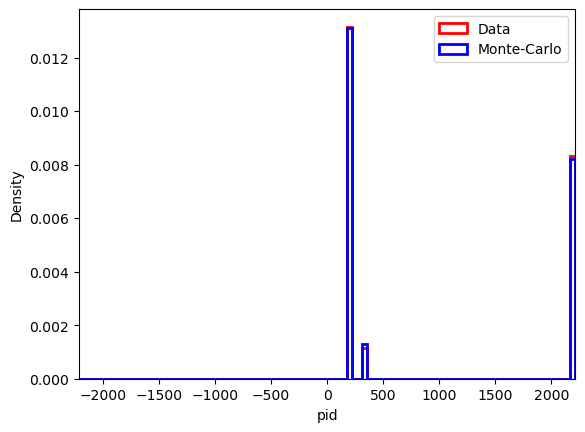

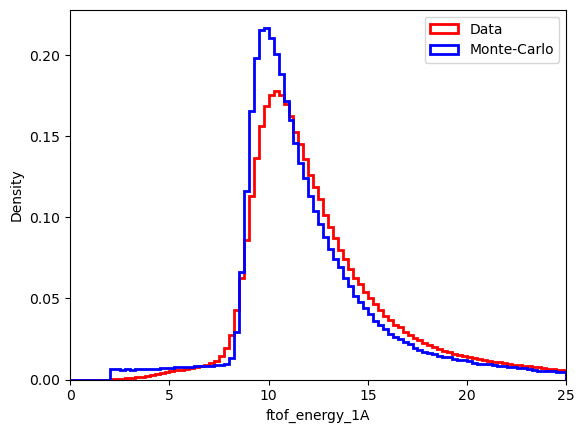

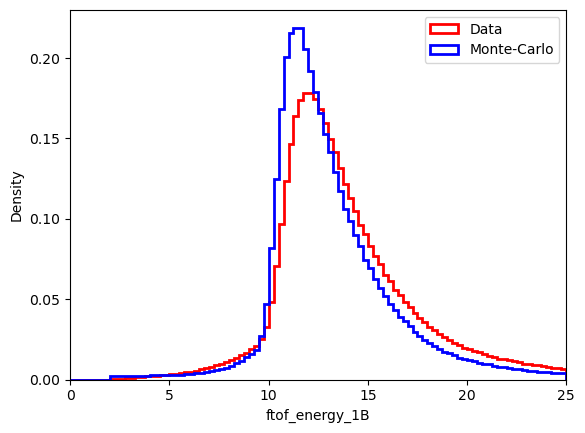

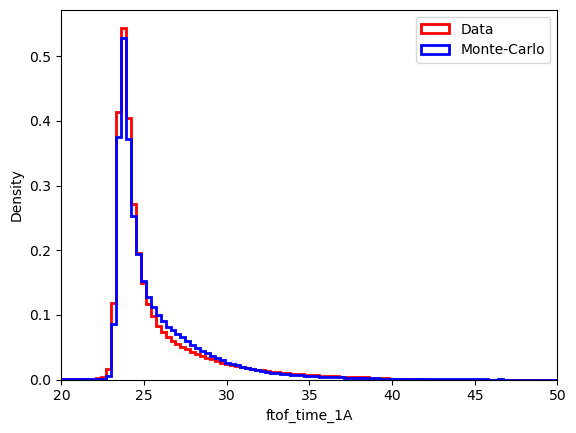

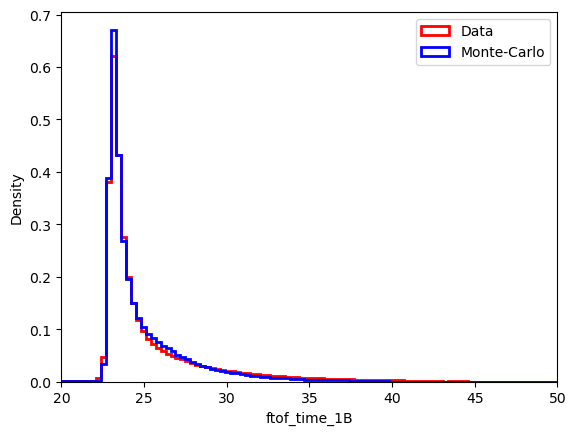

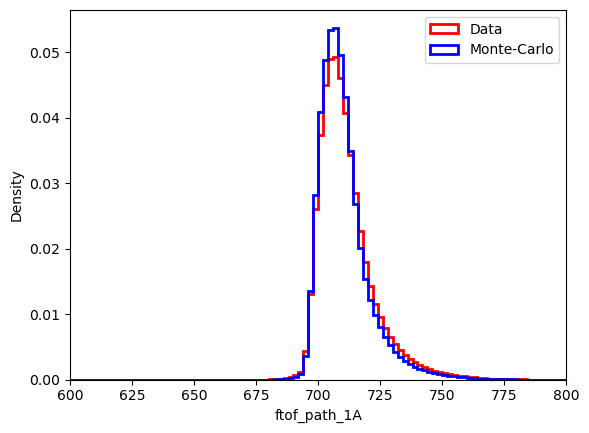

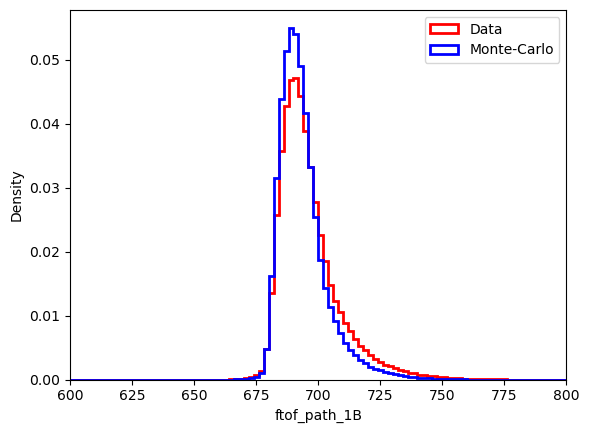

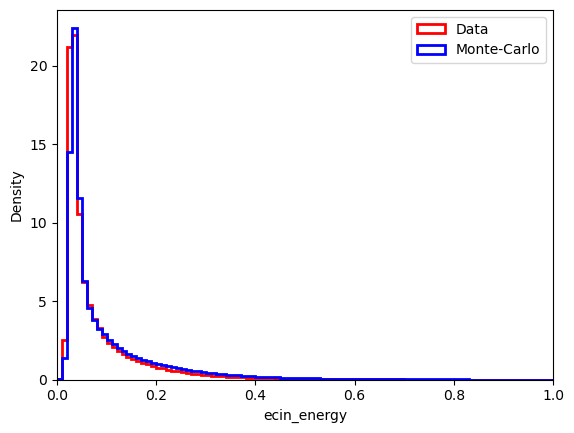

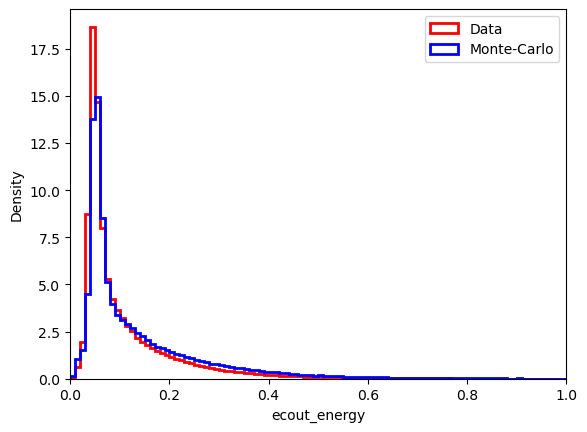

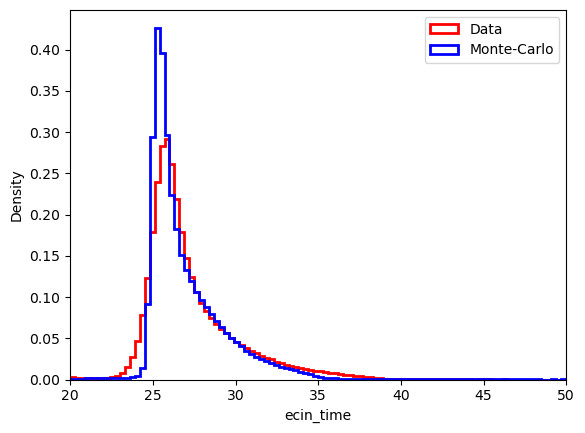

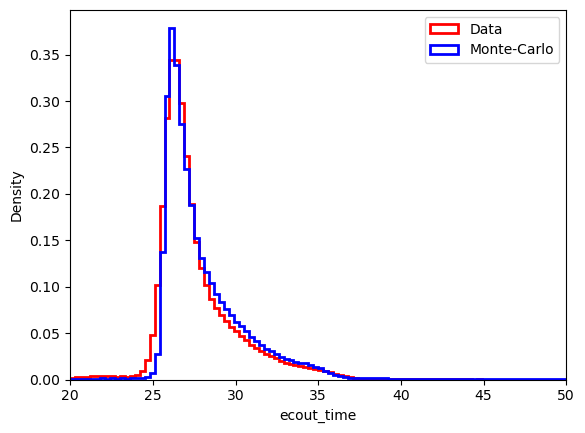

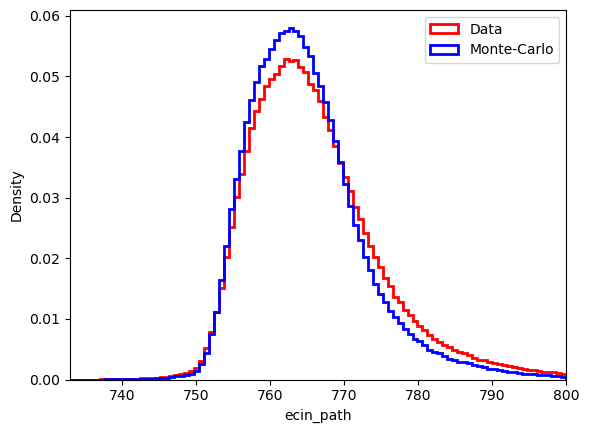

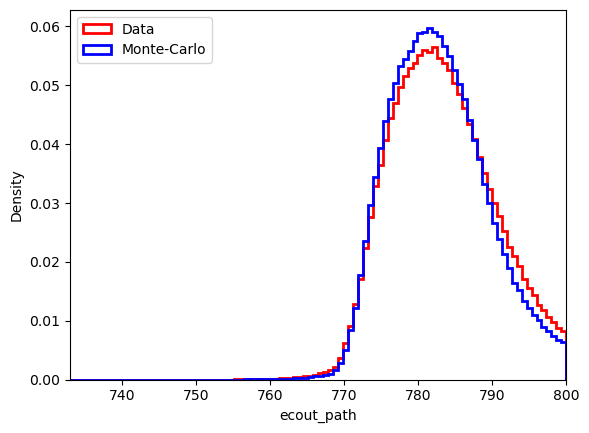

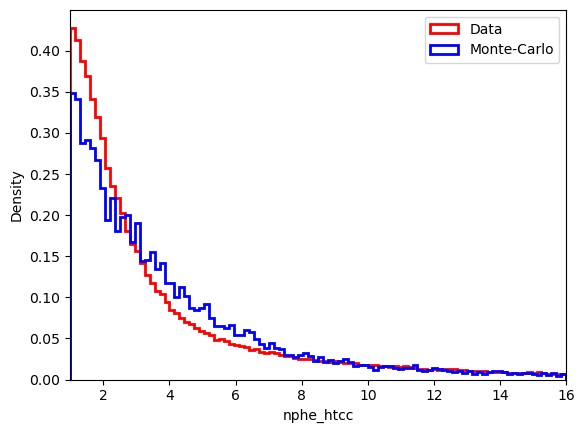

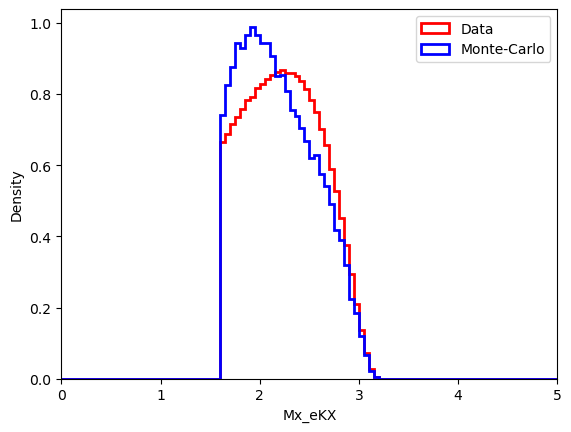

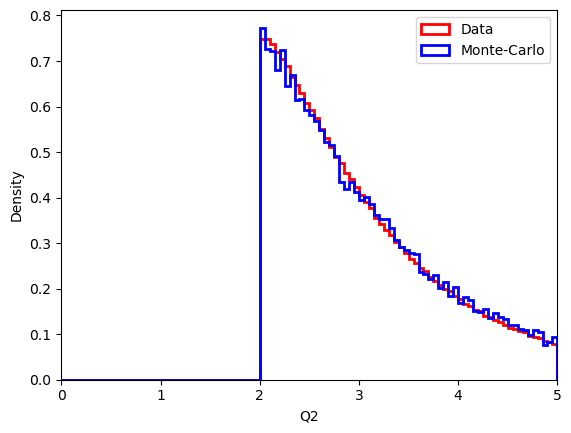

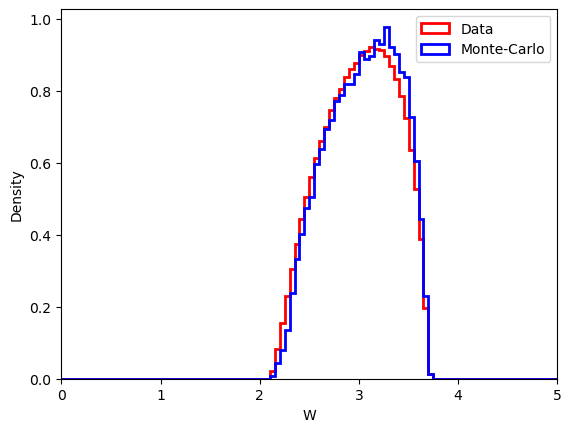

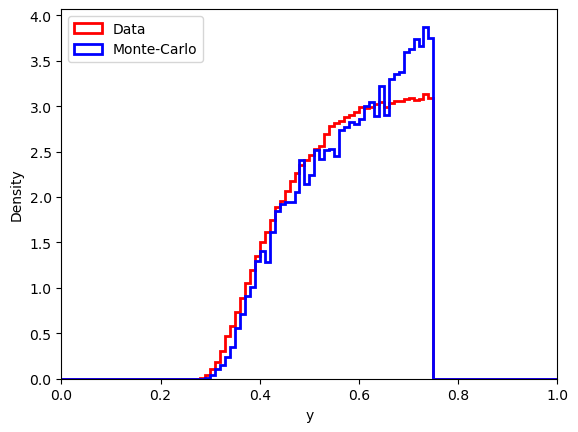

In [7]:
cnt=0
for varbs in cols:
    tdf =df[(df[varbs]!=-9999)]
    treal =real[(real[varbs]!=-9999)]
    dfs=[treal,tdf]
    fig, ax = plt.subplots()
    for i, df in enumerate(dfs):
            ax.hist(
                dfs[i][varbs],
                bins=100,
                range=(ranges[cnt][0], ranges[cnt][1]),
                histtype='step',
                color=colors[i],
                density=True,
                linewidth=2,
                label=labels[i]
            )
    ax.set_xlim(ranges[cnt][0], ranges[cnt][1])
    ax.set_xlabel(varbs)
    ax.set_ylabel("Density")
    ax.legend()
    fig.savefig(direct+varbs+"CompareDATA.png", dpi=150)
    allPlots.append(fig)
    cnt=cnt+1
    plt.show()

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import uproot
import pandas as pd
import matplotlib.ticker as mticker
import math

#cols = ["pid", "mc_matching_pid", "p", "theta", "beta", "chi2pid", "rich_RQ", "vz", "sector", "phi"]
#cols = ["pid","mc_matching_pid","ftof_energy_1A", "ftof_energy_1B", "ftof_time_1A", "ftof_time_1B", "ftof_path_1A", "ftof_path_1B", "ecin_energy", "ecout_energy", "ecin_time", "ecout_time", "ecin_path", "ecout_path", "nphe_htcc"]
cols =["pid","pcal_energy","pcal_time","pcal_path", "ftof_energy_2", "ftof_time_2", "ftof_path_2"]

kinematics =["Mx_eKX", "Q2", "W", "y"]

for kin in kinematics:
    cols.append(kin)

df = uproot.open("/volatile/clas12/cooperb/SULI/pid_training_v2.root:PhysicsEvents").arrays(cols, library="pd")
real=uproot.open("/volatile/clas12/cooperb/SULI/data_pid_training_test.root:PhysicsEvents").arrays(cols, library="pd")
#creates a list of matching events (excludes events that failed matching)

baseline=df[
(df["Q2"]>2)&
(df["W"]>2)&
(df["Mx_eKX"]>1.6)&
((df["y"]>0)&(df["y"]<0.75))
]
df=baseline

baseline=real[
(real["Q2"]>2)&
(real["W"]>2)&
(real["Mx_eKX"]>1.6)&
((real["y"]>0)&(real["y"]<0.75))
]
real=baseline


In [9]:
ranges=[
[-2212, 2212], #pid
[0, 0.9],    #pcal_energy
[20, 50], #pcal_time
[700, 800],  # pcal_path
[0, 16], #ftof_energy_2
[20,50], #ftof_time_2
[600,800], #ftof_path_2
[0,5], #Mx
[0,5], #Q2
[0,5], #W
[0,1] #y    
]    
direct = "/work/clas12/CooperBe/Argonne2026/suli2026_pid/figures/audit/DATAcompare/group3/"  #path directory for saving pngs :)

colors= ["Red", "Blue"]
labels=["Data", "Monte-Carlo"]

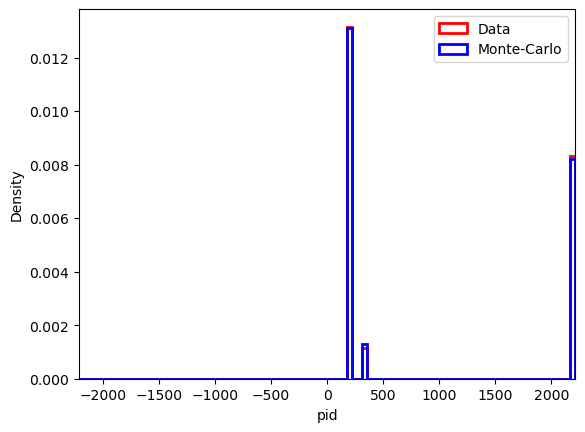

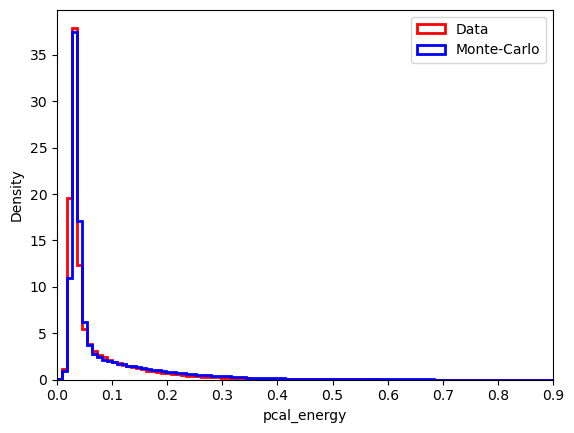

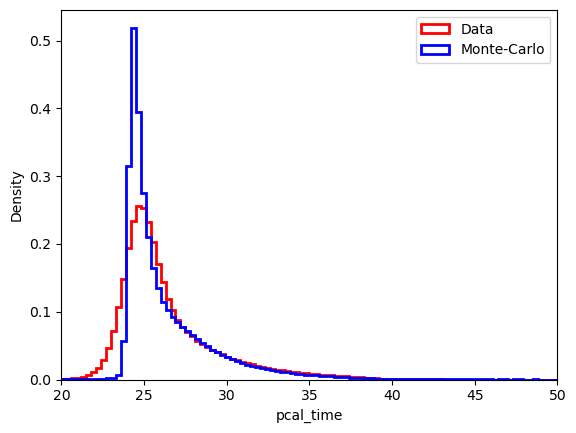

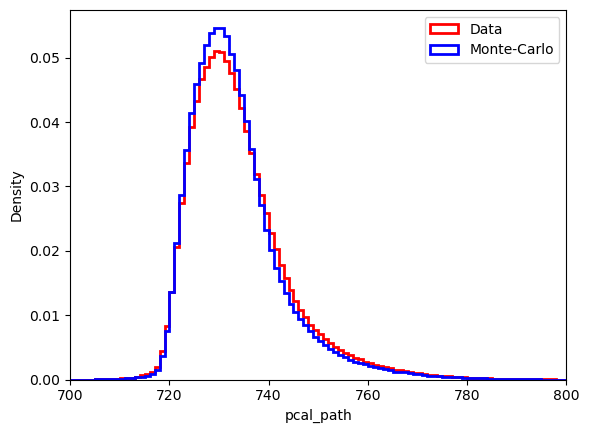

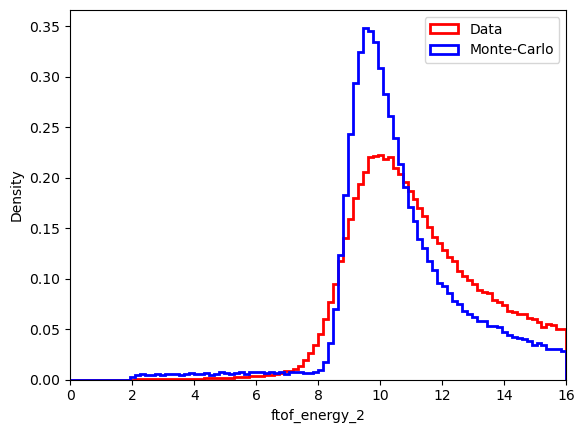

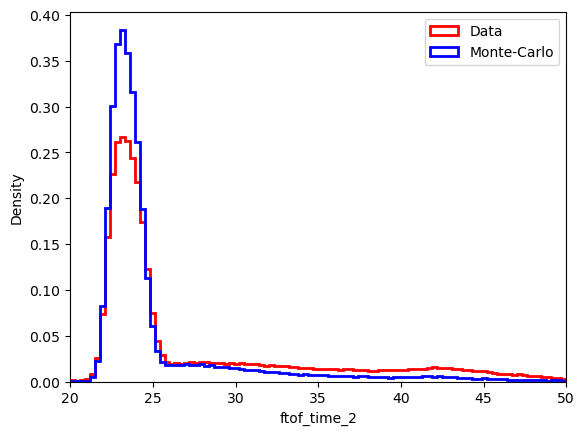

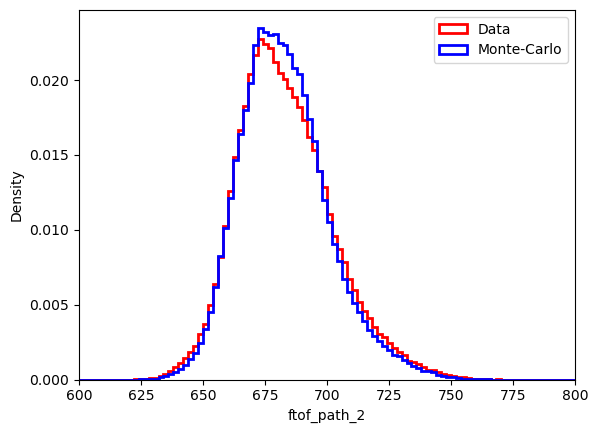

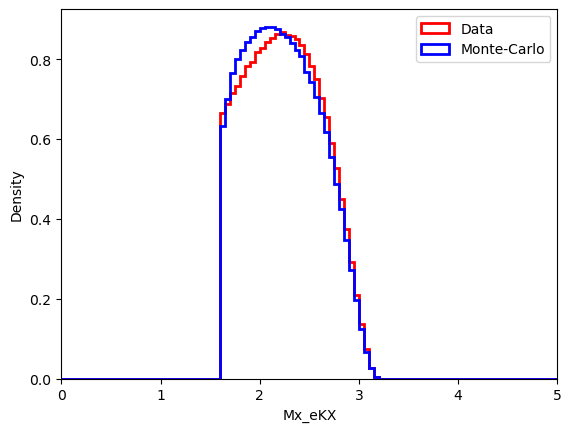

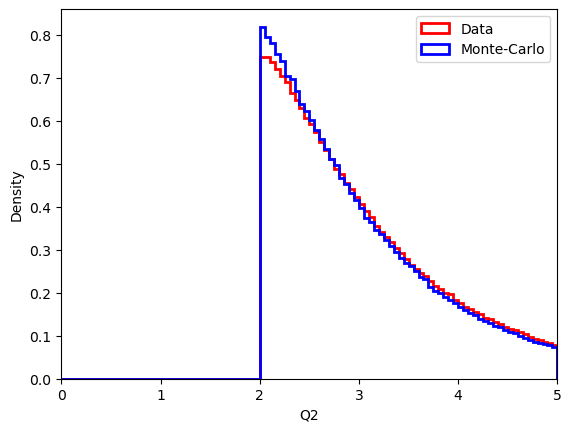

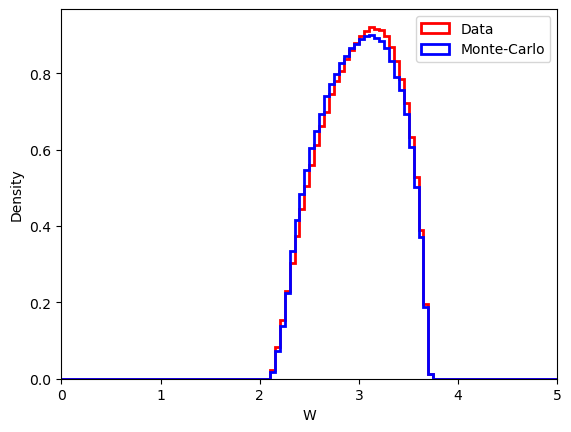

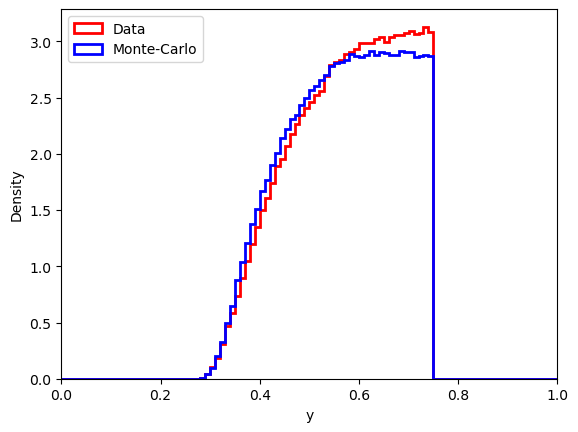

In [10]:
cnt=0
for varbs in cols:
    tdf =df[(df[varbs]!=-9999)]
    treal =real[(real[varbs]!=-9999)]
    dfs=[real,df]
    fig, ax = plt.subplots()
    for i, df in enumerate(dfs):
            ax.hist(
                dfs[i][varbs],
                bins=100,
                range=(ranges[cnt][0], ranges[cnt][1]),
                histtype='step',
                color=colors[i],
                density=True,
                linewidth=2,
                label=labels[i]
            )
    ax.set_xlim(ranges[cnt][0], ranges[cnt][1])
    ax.set_xlabel(varbs)
    ax.set_ylabel("Density")
    ax.legend()
    fig.savefig(direct+varbs+"CompareDATA.png", dpi=150)
    allPlots.append(fig)
    cnt=cnt+1
    plt.show()

In [11]:
with PdfPages("/work/clas12/CooperBe/Argonne2026/suli2026_pid/figures/audit/DATAcompare/" + "CutAllPlotsDataVsMc.pdf") as pdf:
    for plot in allPlots:
        pdf.savefig(plot)